In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("✅ Imports ready")

✅ Imports ready


In [2]:
def generate_gjr_garch_paths(omega, alpha, gamma, beta, 
                              n_paths=10000, 
                              n_days=252, 
                              shock_multiplier=1.0,
                              random_seed=42):
    """
    Generate GJR-GARCH paths with optional shock multiplier.
    """
    np.random.seed(random_seed)
    
    omega_adj = omega * shock_multiplier
    alpha_adj = alpha
    gamma_adj = gamma
    beta_adj = beta
    
    returns = np.zeros((n_paths, n_days))
    sigma2 = np.zeros((n_paths, n_days))
    
    denom = 1 - alpha_adj - beta_adj - gamma_adj/2
    if denom <= 0:
        denom = 0.05
    sigma2[:, 0] = omega_adj / denom
    
    for t in range(1, n_days):
        z = np.random.normal(0, 1, n_paths)
        epsilon2 = returns[:, t-1] ** 2
        I = (returns[:, t-1] < 0).astype(float)
        
        sigma2[:, t] = (omega_adj + 
                        alpha_adj * epsilon2 + 
                        gamma_adj * I * epsilon2 + 
                        beta_adj * sigma2[:, t-1])
        
        sigma2[:, t] = np.maximum(sigma2[:, t], 1e-10)
        returns[:, t] = np.sqrt(sigma2[:, t]) * z
    
    return returns, sigma2

print("✅ GARCH generator defined")

✅ GARCH generator defined


In [3]:
def generate_structural_break_paths(pre_params, post_params, 
                                     n_paths=10000, 
                                     n_days=252, 
                                     break_day=180,
                                     random_seed=42):
    """
    Generate paths with structural break at break_day.
    
    pre_params: dict with omega, alpha, gamma, beta (e.g., normal period)
    post_params: dict with omega, alpha, gamma, beta (e.g., crisis period)
    break_day: day when regime switches
    """
    np.random.seed(random_seed)
    
    n_pre = break_day
    n_post = n_days - break_day
    
    # Generate pre-break paths
    pre_returns, pre_sigma2 = generate_gjr_garch_paths(
        pre_params['omega'], pre_params['alpha'], pre_params['gamma'], pre_params['beta'],
        n_paths=n_paths, n_days=n_pre, shock_multiplier=1.0, random_seed=random_seed
    )
    
    # Generate post-break paths (starting from last volatility of pre period)
    np.random.seed(random_seed + 1)
    
    # Initialize post arrays
    post_returns = np.zeros((n_paths, n_post))
    post_sigma2 = np.zeros((n_paths, n_post))
    
    # First post day uses last pre volatility
    post_sigma2[:, 0] = pre_sigma2[:, -1]
    
    # Crisis parameters
    omega_p = post_params['omega']
    alpha_p = post_params['alpha']
    gamma_p = post_params['gamma']
    beta_p = post_params['beta']
    
    for t in range(1, n_post):
        z = np.random.normal(0, 1, n_paths)
        epsilon2 = post_returns[:, t-1] ** 2
        I = (post_returns[:, t-1] < 0).astype(float)
        
        post_sigma2[:, t] = (omega_p + 
                             alpha_p * epsilon2 + 
                             gamma_p * I * epsilon2 + 
                             beta_p * post_sigma2[:, t-1])
        
        post_sigma2[:, t] = np.maximum(post_sigma2[:, t], 1e-10)
        post_returns[:, t] = np.sqrt(post_sigma2[:, t]) * z
    
    # Combine
    full_returns = np.concatenate([pre_returns, post_returns], axis=1)
    full_sigma2 = np.concatenate([pre_sigma2, post_sigma2], axis=1)
    
    return full_returns, full_sigma2

print("✅ Structural break generator defined")

✅ Structural break generator defined


In [4]:
# Your GARCH parameters (use your actual values)
normal_params = {
    'omega': 0.000161,
    'alpha': 0.0000,
    'gamma': 0.1359,
    'beta': 0.9205,
    'period': '1997-2007'
}

crisis_params = {
    'omega': 0.000284,
    'alpha': 0.0000,
    'gamma': 0.1301,
    'beta': 0.9199,
    'period': '2007-2009'
}

print("Parameters loaded")
print(f"Normal → Crisis break at day 180 (out of 252)")

Parameters loaded
Normal → Crisis break at day 180 (out of 252)


In [5]:
# Generate 10,000 structural break paths
print("Generating structural break paths (Normal → 2008 crisis at day 180)...")
structural_break_returns, structural_break_vol = generate_structural_break_paths(
    pre_params=normal_params,
    post_params=crisis_params,
    n_paths=10000,
    n_days=252,
    break_day=180,
    random_seed=42
)

print(f"Structural break paths shape: {structural_break_returns.shape}")
print(f"Mean volatility (post-break): {structural_break_vol[:, 180:].mean():.4f}%")
print(f"Max volatility: {structural_break_vol.max():.4f}%")

Generating structural break paths (Normal → 2008 crisis at day 180)...
Structural break paths shape: (10000, 252)
Mean volatility (post-break): 0.0154%
Max volatility: 2.0810%


In [6]:
def generate_nonlinear_squeeze(base_params, 
                                n_paths=10000, 
                                n_days=252, 
                                shock_day=200,
                                shock_magnitude=5.0,
                                random_seed=42):
    """
    Generate paths with exponential squeeze shock on shock_day.
    """
    # First generate base paths
    base_returns, base_sigma2 = generate_gjr_garch_paths(
        base_params['omega'], base_params['alpha'], 
        base_params['gamma'], base_params['beta'],
        n_paths=n_paths, n_days=n_days, shock_multiplier=1.0, random_seed=random_seed
    )
    
    # Apply exponential shock on and after shock_day
    # Create multiplier that increases exponentially after shock day
    t = np.arange(n_days)
    multiplier = 1 + (shock_magnitude - 1) * (1 - np.exp(-(t - shock_day)/10))
    multiplier[t < shock_day] = 1
    
    # Apply multiplier to all paths
    squeezed_returns = base_returns * multiplier.reshape(1, -1)
    squeezed_sigma2 = base_sigma2 * multiplier.reshape(1, -1) ** 2
    
    return squeezed_returns, squeezed_sigma2, multiplier

print("✅ Non-linear squeeze generator defined")

✅ Non-linear squeeze generator defined


Generating non-linear squeeze paths...
Squeeze paths shape: (10000, 252)
Multiplier on shock day: 1.00x
Multiplier at end: 4.98x


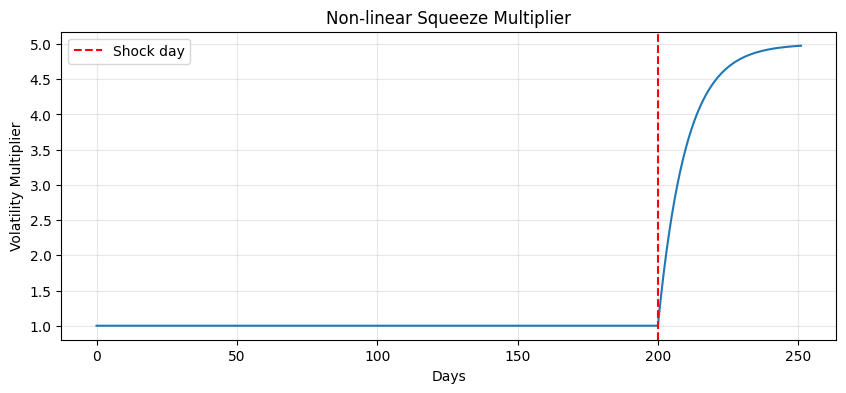

In [7]:
print("Generating non-linear squeeze paths...")
squeeze_returns, squeeze_vol, multiplier = generate_nonlinear_squeeze(
    base_params=normal_params,
    n_paths=10000,
    n_days=252,
    shock_day=200,
    shock_magnitude=5.0,
    random_seed=42
)

print(f"Squeeze paths shape: {squeeze_returns.shape}")
print(f"Multiplier on shock day: {multiplier[200]:.2f}x")
print(f"Multiplier at end: {multiplier[-1]:.2f}x")

# Plot the multiplier
plt.figure(figsize=(10, 4))
plt.plot(multiplier)
plt.axvline(x=200, color='red', linestyle='--', label='Shock day')
plt.title('Non-linear Squeeze Multiplier')
plt.xlabel('Days')
plt.ylabel('Volatility Multiplier')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

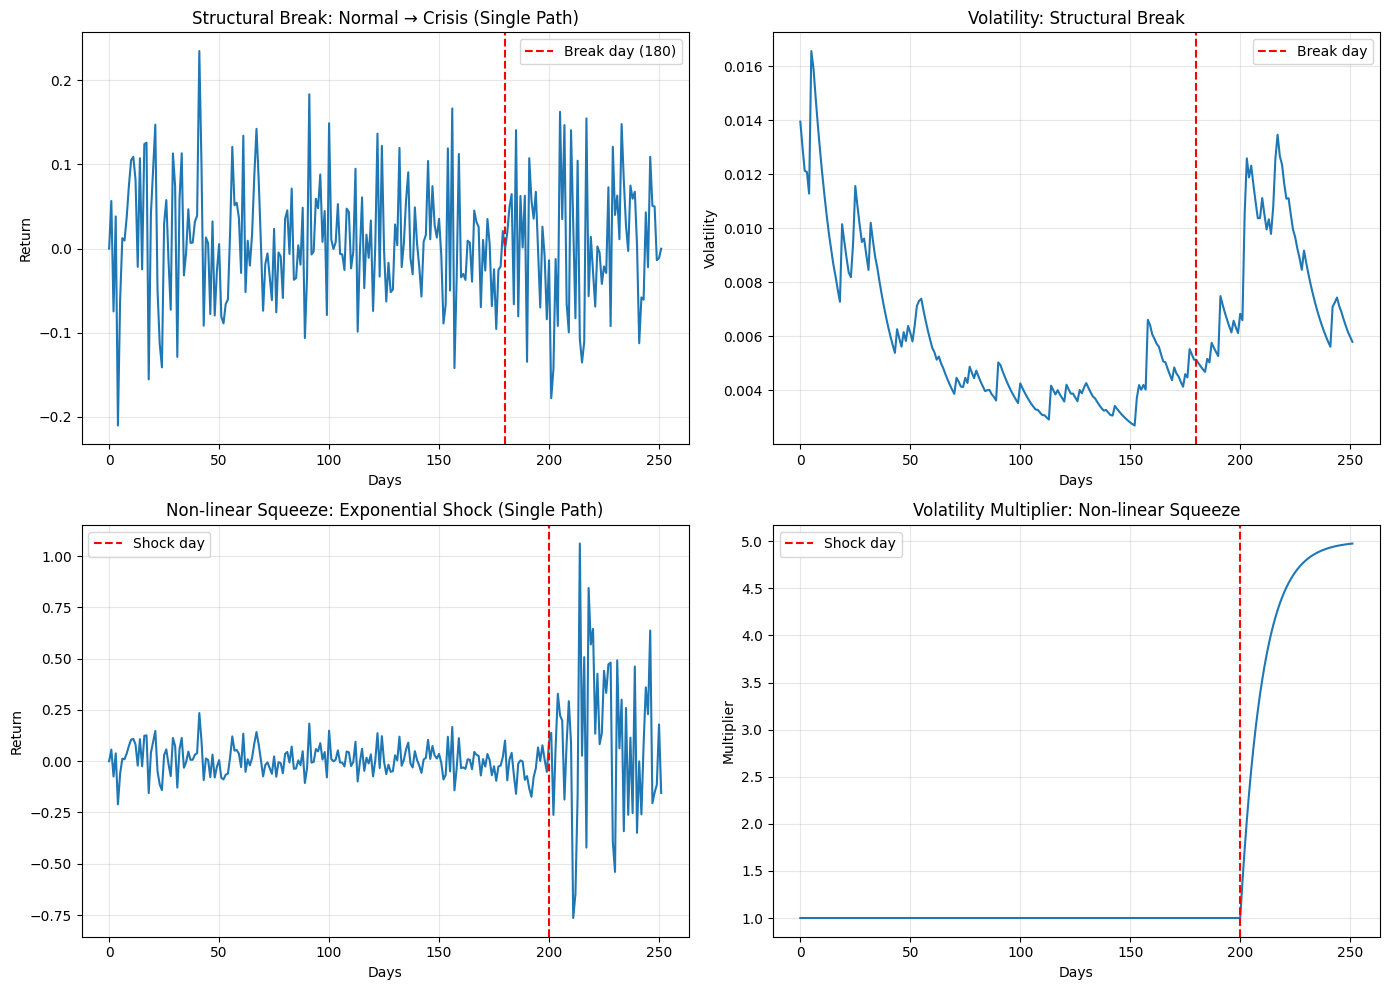

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot first path of structural break
axes[0, 0].plot(structural_break_returns[0, :])
axes[0, 0].axvline(x=180, color='red', linestyle='--', label='Break day (180)')
axes[0, 0].set_title('Structural Break: Normal → Crisis (Single Path)')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Return')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot volatility of structural break
axes[0, 1].plot(structural_break_vol[0, :])
axes[0, 1].axvline(x=180, color='red', linestyle='--', label='Break day')
axes[0, 1].set_title('Volatility: Structural Break')
axes[0, 1].set_xlabel('Days')
axes[0, 1].set_ylabel('Volatility')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot first path of squeeze
axes[1, 0].plot(squeeze_returns[0, :])
axes[1, 0].axvline(x=200, color='red', linestyle='--', label='Shock day')
axes[1, 0].set_title('Non-linear Squeeze: Exponential Shock (Single Path)')
axes[1, 0].set_xlabel('Days')
axes[1, 0].set_ylabel('Return')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot multiplier for squeeze
axes[1, 1].plot(multiplier)
axes[1, 1].axvline(x=200, color='red', linestyle='--', label='Shock day')
axes[1, 1].set_title('Volatility Multiplier: Non-linear Squeeze')
axes[1, 1].set_xlabel('Days')
axes[1, 1].set_ylabel('Multiplier')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/structural_break_squeeze_visualization.png', dpi=150)
plt.show()

In [9]:
from pathlib import Path

Path('../data/simulated').mkdir(parents=True, exist_ok=True)

# Save structural break
np.save('../data/simulated/mc_returns_structural_break.npy', structural_break_returns)
np.save('../data/simulated/mc_volatility_structural_break.npy', structural_break_vol)

# Save non-linear squeeze
np.save('../data/simulated/mc_returns_squeeze.npy', squeeze_returns)
np.save('../data/simulated/mc_volatility_squeeze.npy', squeeze_vol)

print("✅ New scenarios saved!")
print("  - mc_returns_structural_break.npy")
print("  - mc_returns_squeeze.npy")

✅ New scenarios saved!
  - mc_returns_structural_break.npy
  - mc_returns_squeeze.npy


In [11]:
# Load original synthetic for comparison
synthetic_paths = np.load('../data/simulated/mc_returns_synthetic_extreme.npy')

print("\n" + "="*60)
print("VOLATILITY COMPARISON")
print("="*60)

print(f"Original Synthetic (linear 3.0x): mean vol = {synthetic_paths.std(axis=1).mean():.4f}")
print(f"Structural Break: mean vol = {structural_break_returns.std(axis=1).mean():.4f}")
print(f"Non-linear Squeeze: mean vol = {squeeze_returns.std(axis=1).mean():.4f}")


VOLATILITY COMPARISON
Original Synthetic (linear 3.0x): mean vol = 0.1924
Structural Break: mean vol = 0.1133
Non-linear Squeeze: mean vol = 0.2326
